# **Regression Project**

## **Loading data set**

In [61]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load dataset
housing = fetch_california_housing()

# Convert to DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add target column
df['MedHouseVal'] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [62]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

## **Exploratory Data Analysis**

### Features

In [63]:
housing_features=df.drop('MedHouseVal', axis=1)
housing_features

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


### Rows and columns

In [64]:
print("Rows, Columns=", df.shape)

Rows, Columns= (20640, 9)


### Checking for Missing values

In [65]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

### Summary Statistics

In [66]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Target Distrubution

<Axes: >

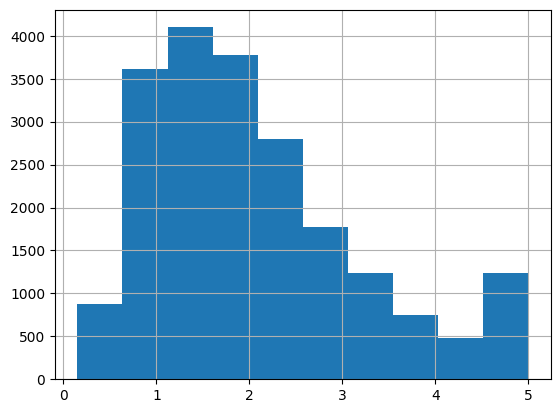

In [67]:
df['MedHouseVal'].hist()  

## **Pipeline**

In [68]:
from sklearn import pipeline
from sklearn.compose import ColumnTransformer



### **Model Testing**

#### Data split

In [69]:
y=df['MedHouseVal']
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [70]:
X=housing_features
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [71]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=100)

In [72]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
3278,3.3929,13.0,8.580645,1.790323,214.0,3.451613,39.14,-122.70
16630,3.2226,11.0,4.927273,1.062121,1814.0,2.748485,35.32,-120.83
18748,3.3500,18.0,5.710638,1.018440,1731.0,2.455319,40.49,-122.31
14961,5.2741,7.0,6.855372,0.979339,862.0,3.561983,32.76,-116.92
1740,2.3382,19.0,4.059891,1.052632,1438.0,2.609800,37.97,-122.34
...,...,...,...,...,...,...,...,...
16304,10.0088,15.0,7.738854,1.003185,1016.0,3.235669,38.01,-121.37
79,2.0114,38.0,4.412903,1.135484,344.0,2.219355,37.80,-122.28
12119,5.6409,3.0,7.837746,1.083262,8437.0,3.602477,33.97,-117.21
14147,2.3812,35.0,6.289474,1.109649,753.0,3.302632,32.74,-117.08


In [73]:
X_test

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
8151,3.7031,36.0,6.276836,1.039548,444.0,2.508475,33.81,-118.10
53,1.2475,52.0,4.075000,1.140000,1162.0,2.905000,37.82,-122.27
3039,4.8266,13.0,6.746647,1.062593,2170.0,3.233979,35.37,-119.12
9484,2.8833,19.0,6.750000,1.348684,424.0,2.789474,39.31,-123.15
9307,2.8903,31.0,4.477459,1.073087,2962.0,2.023224,37.98,-122.52
...,...,...,...,...,...,...,...,...
16733,2.1154,8.0,4.288660,1.247423,936.0,9.649485,35.47,-120.64
5264,11.2866,14.0,7.271898,1.041971,2926.0,2.669708,34.09,-118.57
12374,3.3799,6.0,10.860423,2.036020,4176.0,1.880234,33.78,-116.36
19662,1.7227,52.0,4.954023,1.011494,922.0,2.649425,37.50,-120.85


#### Linear Regression

In [74]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


##### Predictions for LR

In [75]:
y_lr_train_pred = lr.predict(X_train)
y_lr_test_pred = lr.predict(X_test)

In [76]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# for MAE
lr_train_mae = mean_absolute_error(y_train, y_lr_train_pred)

# for MSE
lr_train_mse = mean_squared_error(y_train, y_lr_train_pred)

# for RMSE
lr_train_rmse = np.sqrt(lr_train_mse)

# forR^2
lr_train_r2 = r2_score(y_train, y_lr_train_pred)




print("MAE: ", lr_train_mae)
print("MSE: ", lr_train_mse)
print("RMSE: ", lr_train_rmse)

MAE:  0.5328911953218292
MSE:  0.5282593680413492
RMSE:  0.7268145348308255


#### Random forest

In [77]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(max_depth=2, random_state=100)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

##### Predictions for RF

In [78]:
y_rf_train_pred = rf.predict(X_train)
y_rf_test_pred = rf.predict(X_test)

In [79]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# for MAE
rf_train_mae = mean_absolute_error(y_train, y_rf_train_pred)

# for MSE
rf_train_mse = mean_squared_error(y_train, y_rf_train_pred)

# for RMSE
rf_train_rmse = np.sqrt(rf_train_mse)

# forR^2
rf_train_r2 = r2_score(y_train, y_rf_train_pred)




print("MAE: ", rf_train_mae)
print("MSE: ", rf_train_mse)
print("RMSE: ", rf_train_rmse)

MAE:  0.6438565475951846
MSE:  0.7157535195954227
RMSE:  0.846022174411181


#### Gradient Boosting

In [80]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

##### Predictions for GB

In [81]:
y_gb_train_pred = gb.predict(X_train)
y_gb_test_pred = gb.predict(X_test)

In [82]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# for MAE
gb_train_mae = mean_absolute_error(y_train, y_gb_train_pred)

# for MSE
gb_train_mse = mean_squared_error(y_train, y_gb_train_pred)

# for RMSE
gb_train_rmse = np.sqrt(gb_train_mse)

# forR^2
gb_train_r2 = r2_score(y_train, y_gb_train_pred)




print("MAE: ", gb_train_mae)
print("MSE: ", gb_train_mse)
print("RMSE: ", gb_train_rmse)

MAE:  0.3579216143680141
MSE:  0.26354441372632614
RMSE:  0.5133657699207517


#### LightGBM

In [83]:
from lightgbm import LGBMRegressor
lgb = LGBMRegressor()
lgb.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001426 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071557


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


##### Predictions for LGB

In [84]:
y_lgb_train_pred = lgb.predict(X_train)
y_lgb_test_pred = lgb.predict(X_test)

In [85]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# for MAE
lgb_train_mae = mean_absolute_error(y_train, y_lgb_train_pred)

# for MSE
lgb_train_mse = mean_squared_error(y_train, y_lgb_train_pred)

# for RMSE
lgb_train_rmse = np.sqrt(lgb_train_mse)

# forR^2
lgb_train_r2 = r2_score(y_train, y_lgb_train_pred)




print("MAE: ", lgb_train_mae)
print("MSE: ", lgb_train_mse)
print("RMSE: ", lgb_train_rmse)

MAE:  0.2729320100150835
MSE:  0.15676765273816934
RMSE:  0.395938950771668


## Metric Comparison

In [86]:

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting", "LightGBM"],
    "MAE": [lr_train_mae, rf_train_mae, gb_train_mae, lgb_train_mae],
    "MSE": [lr_train_mse, rf_train_mse, gb_train_mse, lgb_train_mse],
    "RMSE": [lr_train_rmse, rf_train_rmse, gb_train_rmse, lgb_train_rmse]
})

print(results)

               Model       MAE       MSE      RMSE
0  Linear Regression  0.532891  0.528259  0.726815
1      Random Forest  0.643857  0.715754  0.846022
2  Gradient Boosting  0.357922  0.263544  0.513366
3           LightGBM  0.272932  0.156768  0.395939


## Saving the model via Joblib

In [87]:
from joblib import Parallel, delayed
import joblib


# Save the model as a pickle in a file
joblib.dump(lr, 'California homesLR.pkl')

# Load the model from the file
lgb_from_joblib = joblib.load('California homesLR.pkl')

# Use the loaded model to make predictions
lgb_from_joblib.predict(X_test)

array([2.07653781, 1.57976836, 2.08731697, ..., 1.04278469, 1.12583146,
       1.9625772 ], shape=(4128,))

In [88]:
from joblib import Parallel, delayed
import joblib


# Save the model as a pickle in a file
joblib.dump(rf, 'California homes RF.pkl')

# Load the model from the file
lgb_from_joblib = joblib.load('California homes RF.pkl')

# Use the loaded model to make predictions
lgb_from_joblib.predict(X_test)

array([2.09006278, 1.35417798, 2.16376333, ..., 2.09006278, 1.35417798,
       2.09006278], shape=(4128,))

In [89]:
from joblib import Parallel, delayed
import joblib


# Save the model as a pickle in a file
joblib.dump(gb, 'California homes gb.pkl')

# Load the model from the file
lgb_from_joblib = joblib.load('California homes gb.pkl')

# Use the loaded model to make predictions
lgb_from_joblib.predict(X_test)

array([2.20534422, 1.29099737, 1.53687924, ..., 1.85438322, 1.11271803,
       1.37618894], shape=(4128,))

In [90]:
from joblib import Parallel, delayed
import joblib


# Save the model as a pickle in a file
joblib.dump(lgb, 'California homes lgb.pkl')

# Load the model from the file
lgb_from_joblib = joblib.load('California homes lgb.pkl')

# Use the loaded model to make predictions
lgb_from_joblib.predict(X_test)

array([2.30702401, 1.27679974, 1.27285614, ..., 1.68356151, 0.95599056,
       1.25243113], shape=(4128,))